In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath('..'))

In [2]:
import photospline

from icecube import dataio, icetray, dataclasses, simclasses
import numpy.random as random
import numpy as np
import scipy.optimize as optimize
import matplotlib.pyplot as plt
from scripts.SplineEval import evalLogPdf, evalPdf
from matplotlib.colors import LogNorm


In [26]:
file_500 = dataio.I3File('../nue_data/gen_500.i3.zst')
file_012 = dataio.I3File('../nue_data/gen_012.i3.zst')
gcd = dataio.I3File('../gcdfile/PONE_800mGrid.i3.gz')

iter = 0
for frame in file_500:
    if iter == 17:
        frame18 = frame
    if iter == 26:
        frame27 = frame

    if iter == 92:
        frame93 = frame
    if iter == 127:
        frame128 = frame
    
    iter += 1
iter = 0
for frame in file_012:
    if iter == 69:
        frame70 = frame
    
    if iter == 115:
        frame115 = frame
    iter += 1
for frame in gcd:
    gcdframe = frame
    break

In [4]:
string_subset = np.array([266, 199, 220, 275,  96, 113, 112, 286, 173, 116,   8, 240, 130,
       307, 281, 112, 324, 306, 183, 303, 314, 289,  72, 113, 147, 177,
       160,  57,  54, 142, 291, 204,  75, 215, 179, 143, 315, 201, 182,
        78,  60,   1, 326,  46, 272, 232, 134, 162, 268, 101, 139, 320,
       195,  11,  86, 300,  84,  67, 129,  63, 310,  59, 215, 312, 188,
       138,  71, 120, 139,  12,  26, 117, 129,  40,   6, 156,  79, 132,
       127, 161])

In [29]:
c = 299792458
n = 1.34
def datacollect(frame):
    dt = []
    t = []
    dphilst = []
    dr = []
    xyz = []
    

    Epos = frame['I3MCTree'][1].pos
    doms = gcdframe['I3ModuleGeoMap']
    omkeys = frame['I3Photons'].keys()
    photons = frame['I3Photons']
    for key in omkeys:
        # if key.string not in string_subset:
        #     continue
        modulekey = dataclasses.ModuleKey(key.string, key.om)
        dompos = doms[modulekey].pos
        for photon in photons[key]:
            photon_pos = dompos + photon.pos
            xyz.append([photon_pos.x, photon_pos.y, photon_pos.z])
            flight = dompos + photon.pos - Epos
            dr.append(flight.magnitude)
            offset = flight.magnitude * n / c
            dt.append(photon.time - offset*10**9)
            t.append(photon.time)
            phi = photon.dir
            randx, randy, randz = random.uniform(-1, 1, 3)
            x = phi.x
            y = phi.y
            z = phi.z
            dx = x - randx
            dy = y - randy
            dz = z - randz
            dphi = dataclasses.I3Direction(dx, dy, dz)
            dphilst.append(dphi.zenith)
            # Etheta.append(flight.azimuth)
            # Ephi.append(flight.zenith)
            
    return np.column_stack([xyz, t, dt])
    
    

In [6]:
frame18['I3MCTree'][0].energy

1865.6831830418678

In [28]:
EventData1 = datacollect(frame18)
EventData2 = datacollect(frame27)
EventData3 = datacollect(frame70)
EventData4 = datacollect(frame93)
EventData5 = datacollect(frame128)
#EventData6 = datacollect(frame115)

In [14]:
len(EventData1)

11126

In [15]:
splinefit_3d = photospline.SplineTable('../fits/splinelog_3D.fits')

In [16]:
def displacement_magnitude(pos1: np.array, pos2: np.array) -> float:
    vector = pos1 - pos2
    return np.sqrt(vector[0]**2 + vector[1]**2 + vector[2]**2)

In [17]:
def Likelihood_3d(coords: np.array, Event: np.array = EventData1):
    L = 0
    # coords should have shape [x,y,z,theta,phi,t]
    # Event has shape [N, 6] cols:(x,y,z,t,dr,dt). We only use the first 4 here
    
    event_xyz = Event[:,0:3]
    event_t = Event[:,3]
    
    
    
    # Calculate Displacement Magnitude
    diff = coords[0:3] - event_xyz
    dr = np.linalg.norm(diff, axis=1)
    # Calculate Time Residual
    dt = abs(coords[5] - event_t) - (1.34*dr/c * 1e9)

    # Construct Electron direction unit vector from zenith and azimuth
    Ex = np.sin(coords[4])*np.cos(coords[3])
    Ey = np.sin(coords[4])*np.sin(coords[3])
    Ez = np.cos(coords[4])


    # Calculate angle between electron travel vector and displacement vector
    Eangle = np.array([Ex, Ey, Ez])
    Ephi = np.arccos(np.dot(diff, Eangle) / dr)
    #print(Ephi)
    #Calculate Likelihood from constructed coordinates
    params = np.array([dr, Ephi, dt])
    vals = splinefit_3d.evaluate_simple([params[0], params[1], params[2]])
    L = np.where(vals == 0, -30, vals)
    return -np.sum(L)


In [18]:
Likelihood_3d(np.array([2.86453, 216.537, 254.435, 5.03732, 1.12255, 0]), EventData1)

34526.78937447071

In [13]:
truth = np.array([2.86453, 216.537, 254.435, 0])
def Likelihood_3d_calculation(truth, Event) -> None:
    xary = np.linspace(truth[0] - 150, truth[0] + 150, 500)
    yary = np.linspace(truth[1] - 150, truth[1] + 150, 500)
    zary = np.linspace(truth[2] - 150, truth[2] + 150, 500)
    tary = np.linspace(truth[5] - 500, truth[5] + 500, 500)
    # phiary = np.linspace((truth[4] - 0.3), (truth[4]+0.3), 500)
    # ThetaAry = np.linspace((truth[3] - 0.3), (truth[3]+0.3), 500)
    phiary = np.linspace(0, np.pi, 500)
    ThetaAry = np.linspace(0, 2*np.pi, 500)


    xplot = []
    yplot = []
    zplot = []
    tplot = []
    phiplot = []
    thetaplot = []
    for i in range(len(xary)):
        xplot.append(Likelihood_3d(np.array([xary[i], truth[1], truth[2], truth[3], truth[4], truth[5]]), Event=Event))
        yplot.append(Likelihood_3d(np.array([truth[0], yary[i], truth[2], truth[3], truth[4], truth[5]]), Event=Event))
        zplot.append(Likelihood_3d(np.array([truth[0], truth[1], zary[i], truth[3], truth[4], truth[5]]), Event=Event))
        tplot.append(Likelihood_3d(np.array([truth[0], truth[1], truth[2], truth[3], truth[4], tary[i]]), Event=Event))
        phiplot.append(Likelihood_3d(np.array([truth[0], truth[1], truth[2], truth[3], phiary[i], truth[5]]), Event=Event))
        thetaplot.append(Likelihood_3d(np.array([truth[0], truth[1], truth[2], ThetaAry[i], truth[4], truth[5]]), Event=Event))

    return [xplot, yplot, zplot, thetaplot, phiplot, tplot]


In [14]:
def likelihood_graphs(truth, data, filename:str):
    xary = np.linspace(truth[0] - 150, truth[0] + 150, 500)
    yary = np.linspace(truth[1] - 150, truth[1] + 150, 500)
    zary = np.linspace(truth[2] - 150, truth[2] + 150, 500)
    tary = np.linspace(truth[5] - 500, truth[5] + 500, 500)
    # phiary = np.linspace((truth[4] - 0.3)*360/(2*np.pi), (truth[4]+0.3)*360/(2*np.pi), 500)
    # ThetaAry = np.linspace((truth[3] - 0.3)*360/(2*np.pi)-10, (truth[3]+0.3)*360/(2*np.pi), 500)
    phiary = np.linspace(0, 180, 500)
    ThetaAry = np.linspace(0, 360, 500)

    
    fig, axs = plt.subplots(2, 3, figsize=(12,10))
    
    axs[0,0].plot(xary, data[0])
    axs[0,0].set_title('Likelihood Evolution in X')
    axs[0,0].set_xlabel('X (m)')
    axs[0,0].set_ylabel('-ln(L)')
    axs[0,0].vlines(truth[0], min(data[0]), max(data[0]), label = 'Truth', colors = 'red', ls = '--')
    axs[0,0].grid()
    # axs[0,0].set_ylim(min(data[0]) - 40, min(data[0]) + 100)
    # axs[0,0].set_xlim(truth[0] - 1, truth[0] + 1)
    # #axs[0,0].set_yscale('log')
    axs[0,0].legend()


    axs[0,1].plot(yary, data[1])
    axs[0,1].set_title('Likelihood Evolution in Y')
    axs[0,1].set_xlabel('Y (m)')
    axs[0,1].set_ylabel('-ln(L)')
    axs[0,1].grid()
    # axs[0,1].set_ylim(min(data[1]) - 40, min(data[1]) + 700)
    # axs[0,1].set_xlim(truth[1] - 1, truth[1] + 1)
    # #axs[0,1].set_yscale('log')
    axs[0,1].vlines(truth[1], min(data[1]), max(data[1]), label = 'Truth', colors = 'red', ls = '--')
    axs[0,1].legend()


    axs[1,0].plot(zary, data[2])
    axs[1,0].set_title('Likelihood Evolution in Z')
    axs[1,0].set_xlabel('Z (m)')
    axs[1,0].set_ylabel('-ln(L)')
    # axs[1,0].set_ylim(min(data[2]) - 40, min(data[2]) + 100)
    # axs[1,0].set_xlim(truth[2] - 1, truth[2] + 1)
    # #axs[1,0].set_yscale('log')
    axs[1,0].vlines(truth[2], min(data[2]), max(data[2]), label = 'Truth', colors = 'red', ls = '--')
    axs[1,0].grid()
    axs[1,0].legend()


    axs[1,1].plot(tary, data[5])
    axs[1,1].set_title('Likelihood Evolution in t')
    axs[1,1].set_xlabel('t (ns)')
    axs[1,1].set_ylabel('-ln(L)')
    # axs[1,1].set_xlim(truth[5] - 3, truth[5] + 3)
    # axs[1,1].set_ylim(min(data[5]) - 100, min(data[5]) + 500)
    # #axs[1,1].set_yscale('log')
    axs[1,1].vlines(truth[5], min(data[5]), max(data[5]), label = 'Truth', colors = 'red', ls = '--')
    axs[1,1].grid()
    axs[1,1].legend()

    axs[1,2].plot(ThetaAry, data[3])
    axs[1,2].set_title('Likelihood Evolution in Azimuth')
    axs[1,2].set_xlabel('Azimuth (deg)')
    axs[1,2].set_ylabel('-ln(L)')
    axs[1,2].vlines(truth[3]*360/(2*np.pi), min(data[3]), max(data[3]), label = 'Truth', colors = 'red', ls = '--')
    axs[1,2].grid()
    # axs[1,2].set_ylim(min(data[3]) - 40, min(data[3]) + 800)
    # axs[1,2].set_xlim(truth[3]*360/(2*np.pi) - 0.3*360/(2*np.pi), truth[3]*360/(2*np.pi) + 0.3*360/(2*np.pi))
    # axs[1,2].set_yscale('log')
    axs[1,2].legend()

    axs[0,2].plot(phiary, data[4])
    axs[0,2].set_title('Likelihood Evolution in Zenith')
    axs[0,2].set_xlabel('Zenith (deg)')
    axs[0,2].set_ylabel('-ln(L)')
    axs[0,2].vlines(truth[4]*360/(2*np.pi), min(data[4]), max(data[4]), label = 'Truth', colors = 'red', ls = '--')
    axs[0,2].grid()
    # axs[0,2].set_ylim(min(data[4]) - 40, min(data[4]) + 100)
    # axs[0,2].set_xlim(truth[4]*360/(2*np.pi) - 0.05*360/(2*np.pi), truth[4]*360/(2*np.pi) + 0.05*360/(2*np.pi))
    # # axs[0,2].set_yscale('log')
    axs[0,2].legend()

    fig.tight_layout()
    fig.savefig(f'../plots/{filename}.png')

In [15]:
likelihood_data = Likelihood_3d_calculation(np.array([2.86453,216.537,254.435, 5.03732, 1.12255, 0]), EventData1)

In [16]:
print(frame18['I3MCTree'][1].pos)
print(frame18['I3MCTree'][1].time)
print(frame18['I3MCTree'][1])

I3Position(2.86453,216.537,254.435)
0.0
[ I3Particle MajorID : 15941211553967342775
             MinorID : 614
              Zenith : 1.12255
             Azimuth : 5.03732
                   X : 2.86453
                   Y : 216.537
                   Z : 254.435
                Time : 0
              Energy : 1847.28
               Speed : 0.299792
              Length : nan
                Type : EMinus
        PDG encoding : 11
               Shape : Cascade
              Status : NotSet
            Location : InIce
]


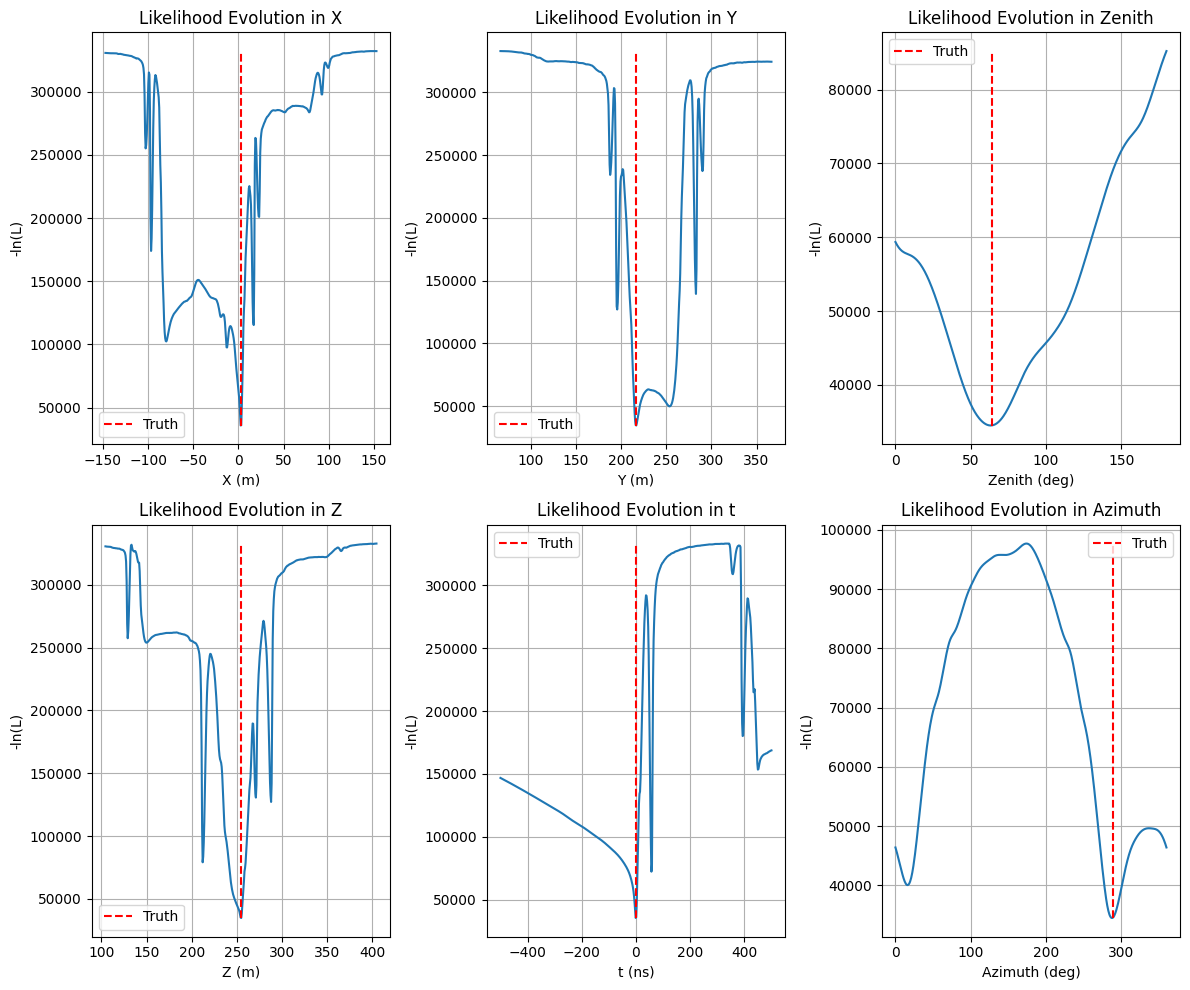

In [17]:
likelihood_graphs(np.array([2.86453,216.537,254.435, 5.03732, 1.12255, 0]), likelihood_data, 'likelihood_evo_80str')


In [18]:
def minimizer(guess, event, function=Likelihood_3d):
    # Guess should be xyzt
    minimized = optimize.minimize(function, 
                                  x0=guess,
                                  args=(event),  
                                  method='Nelder-Mead', 
                                  tol=1e-3)
    return minimized

In [19]:
minimizer(np.array([2.86453,216.537,254.435, 5.03732, 1.12255, 0]), EventData1)

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 33260.68909716606
             x: [ 2.787e+00  2.173e+02  2.551e+02  4.981e+00  9.819e-01
                 -2.515e-04]
           nit: 155
          nfev: 252
 final_simplex: (array([[ 2.787e+00,  2.173e+02, ...,  9.819e-01,
                        -2.515e-04],
                       [ 2.787e+00,  2.173e+02, ...,  9.819e-01,
                        -2.512e-04],
                       ...,
                       [ 2.786e+00,  2.173e+02, ...,  9.819e-01,
                        -2.511e-04],
                       [ 2.787e+00,  2.173e+02, ...,  9.820e-01,
                        -2.548e-04]]), array([ 3.326e+04,  3.326e+04,  3.326e+04,  3.326e+04,
                        3.326e+04,  3.326e+04,  3.326e+04]))

In [20]:
space_angle_ary = np.array([])
energy_ary = np.array([])
for i in range(501):
    if i < 10:
        runnumber = '00' + str(i)
    elif i < 100:
        runnumber = '0' + str(i)
    else:
        runnumber = str(i)
    if os.path.isfile(f'/mnt/scratch/dillonb5/resolutions_80str/resolution_{runnumber}.npy'):
        #print(runnumber)
        ary = np.load(f'/mnt/scratch/dillonb5/resolutions_80str/resolution_{runnumber}.npy')
    
        if ary.shape == (0,):
            continue
       

        # zenith_ary = np.concatenate((zenith_ary, ary[:,0]))
        # azimuth_ary = np.concatenate((azimuth_ary, ary[:,1]))
        space_angle_ary = np.concatenate((space_angle_ary, ary[:,0]))
        energy_ary = np.concatenate((energy_ary, ary[:,1]))


In [21]:
len(space_angle_ary)

14566

In [22]:
space_angle_ary = space_angle_ary*360/(2*np.pi)

In [23]:
space_angle_ary

array([42.2152582 ,  7.83137182, 38.40023154, ...,  1.57285607,
       10.79123599, 31.01457916])

In [24]:
count=0
for val in space_angle_ary:
    if not np.isnan(val):
        count+=1
print(count)

14566


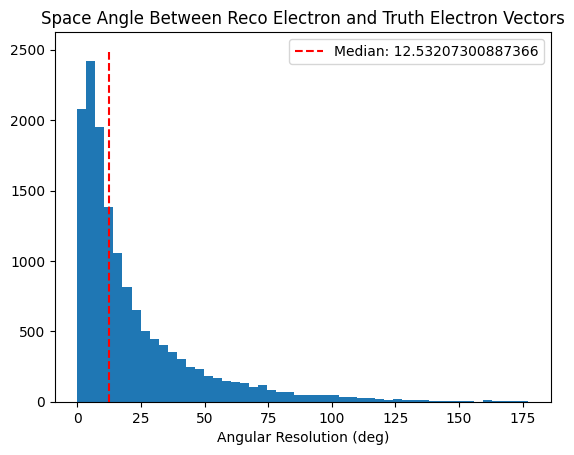

In [25]:
plt.hist(space_angle_ary, 50)
plt.vlines(np.median(space_angle_ary), 0, 2500, colors='red', ls='--', label=f'Median: {np.median(space_angle_ary)}')
plt.title('Space Angle Between Reco Electron and Truth Electron Vectors')
plt.xlabel('Angular Resolution (deg)')
plt.legend()
plt.savefig(
    '/mnt/home/dillonb5/cascades/plots/angular_res_v1.png'
)

In [26]:
hist, edges = np.histogram(energy_ary, bins=np.logspace(2, 6, 17))
print(hist)
print(edges)

[4487 3070 2144 1362  989  682  502  356  272  186  135  112   86   89
   64   30]
[1.00000000e+02 1.77827941e+02 3.16227766e+02 5.62341325e+02
 1.00000000e+03 1.77827941e+03 3.16227766e+03 5.62341325e+03
 1.00000000e+04 1.77827941e+04 3.16227766e+04 5.62341325e+04
 1.00000000e+05 1.77827941e+05 3.16227766e+05 5.62341325e+05
 1.00000000e+06]


In [27]:
def truncate(f, n):
        '''Truncates/pads a float f to n decimal places without rounding'''
        s = '{}'.format(f)
        if 'e' in s or 'E' in s:
                return '{0:.{1}f}'.format(f, n)
        i, p, d = s.partition('.')
        return '.'.join([i, (d+'0'*n)[:n]])

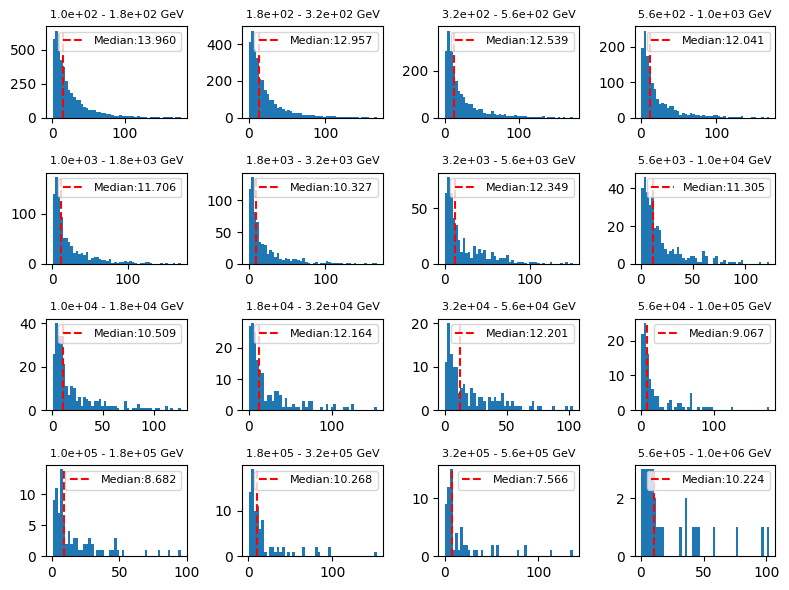

In [28]:
fig, axs = plt.subplots(4,4, figsize = (8,6))
ct = 0
for i in range(len(axs)):
    for j in range(len(axs[i])):
        bin_mask = (energy_ary >= edges[ct]) & (energy_ary < edges[ct + 1])
        bin_res = space_angle_ary[bin_mask]
        counts, _ = np.histogram(bin_res, bins=50)
        axs[i,j].hist(bin_res, bins=50)
        axs[i,j].set_title(f'{edges[ct]:.1e} - {edges[ct+1]:.1e} GeV', fontsize=8)
        axs[i,j].vlines(np.median(bin_res), 0, max(counts), colors='red', ls='--', label=f'Median:{truncate(np.median(bin_res),3)}')
        #axs[i,j].set_xlabel('Angular Resolution (deg)', fontsize=8)
        axs[i,j].legend(fontsize=8)
        
        ct += 1

fig.tight_layout()
plt.savefig('/mnt/home/dillonb5/cascades/plots/angular_res_energy_binned.png')



In [29]:
splinefit_3d.extents

((2.0920000317428116, 279.13374889976023),
 (0.0, 3.141592653589793),
 (-30.726762008826114, 1627.6756954685331))

In [19]:
def cdf(coords, Event):
    t = np.linspace(splinefit_3d.extents[2][0], splinefit_3d.extents[2][1], 2500)
    pvalues = []
    for event in Event:
        dr = displacement_magnitude(coords[0:3], np.array(event[0:3]))
        diff = coords[0:3] - np.array(event[0:3])

        Ex = np.sin(coords[4])*np.cos(coords[3])
        Ey = np.sin(coords[4])*np.sin(coords[3])
        Ez = np.cos(coords[4])


        # Calculate angle between electron travel vector and displacement vector
        Eangle = np.array([Ex, Ey, Ez])
        Ephi = np.arccos(np.dot(diff, Eangle) / dr)
        
        
        #dt = abs(coords[3] - event[3]) - (1.34*dr/c * 1e9)
        #pdf = evalPdf(splinefit_3d, dr, Ephi, t)
        pdf = np.exp(splinefit_3d.evaluate_simple([dr, Ephi, t]))
        cdf = np.sum(pdf[np.searchsorted(t, event[-1]):])/np.sum(pdf)
        pvalues.append(cdf)

    plt.hist(pvalues, bins=np.linspace(min(pvalues),max(pvalues),50))
    plt.xlabel('CDF Value')
    plt.ylabel('Hits')
    plt.title('3D CDF Distribution')

In [31]:
len(EventData5)

53819

In [32]:
def cdf_color_plt(coords, Event):
    pvalues = []
    for event in Event:
        dr = displacement_magnitude(coords[0:3], np.array(event[0:3]))
        diff = coords[0:3] - np.array(event[0:3])

        Ex = np.sin(coords[4])*np.cos(coords[3])
        Ey = np.sin(coords[4])*np.sin(coords[3])
        Ez = np.cos(coords[4])


        # Calculate angle between electron travel vector and displacement vector
        Eangle = np.array([Ex, Ey, Ez])
        Ephi = np.arccos(np.dot(diff, Eangle) / dr)
        
        
        #dt = abs(coords[3] - event[3]) - (1.34*dr/c * 1e9)
        pdf = np.exp(splinefit_3d.evaluate_simple([dr,Ephi, t]))
        cdf = np.sum(pdf[np.searchsorted(t, event[-1]):])/np.sum(pdf)
        pvalues.append((cdf, Ephi))
    twoDary = np.array(pvalues)
    #print(twoDary)
    hist, edges = np.histogramdd(twoDary, bins=20)
    print(twoDary)
    
    fig, ax = plt.subplots()
    plot = ax.imshow(
        hist.T,                    # Transpose so axis 0 = x, axis 1 = y
        origin='lower',            # Put (0,0) at bottom-left, not top-left
        aspect='auto',
        norm=LogNorm(vmin=1, vmax=hist.max()),             # Don't force square pixels
        extent=[                   # Map pixel coords to data coords
            edges[0][0], edges[0][-1],   # x: cdf axis range
            edges[1][0], edges[1][-1]    # y: dr axis range
        ]
    )
    cbar = ax.figure.colorbar(plot, ax=ax, )
    cbar.ax.set_ylabel('Bin counts', rotation=-90, va="bottom")
    ax.set_xlabel('CDF')
    ax.set_ylabel('Emission Angle')
    plt.tight_layout()
    plt.show()

In [33]:
#cdf_color_plt(np.array([632.878,-456.534,-261.346, 0.938481, 2.22391,0]), EventData2)

In [20]:
sampled_file = dataio.I3File('/mnt/scratch/dillonb5/sampled_data_3d/new_030.i3.zst')

i=0
frame_list = []
for i in range(100):
    if i < 10:
        n = '00'+str(i)
    else:
        n = '0'+str(i)
    sampled_file = dataio.I3File(f'/mnt/scratch/dillonb5/sampled_data_3d/new_{n}.i3.zst')
    print(f'file {n} loaded')

    for frame in sampled_file:
        
        if len(frame['I3Photons']) != 0:
            frame_list.append(frame)
    print('inner loop')
    

file 000 loaded
inner loop
file 001 loaded
inner loop
file 002 loaded
inner loop
file 003 loaded
inner loop
file 004 loaded
inner loop
file 005 loaded
inner loop
file 006 loaded
inner loop
file 007 loaded
inner loop
file 008 loaded
inner loop
file 009 loaded
inner loop
file 010 loaded
inner loop
file 011 loaded
inner loop
file 012 loaded
inner loop
file 013 loaded
inner loop
file 014 loaded
inner loop
file 015 loaded
inner loop
file 016 loaded
inner loop
file 017 loaded
inner loop
file 018 loaded
inner loop
file 019 loaded
inner loop
file 020 loaded
inner loop
file 021 loaded
inner loop
file 022 loaded
inner loop
file 023 loaded
inner loop
file 024 loaded
inner loop
file 025 loaded
inner loop
file 026 loaded
inner loop
file 027 loaded
inner loop
file 028 loaded
inner loop
file 029 loaded
inner loop
file 030 loaded
inner loop
file 031 loaded
inner loop
file 032 loaded
inner loop
file 033 loaded
inner loop
file 034 loaded
inner loop
file 035 loaded
inner loop
file 036 loaded
inner loop
f

In [22]:
datacollect(frame18)

TypeError: can't multiply sequence by non-int of type 'float'

In [41]:
frame_list[-1]

In [ ]:
len(EventdataSampled)

1069

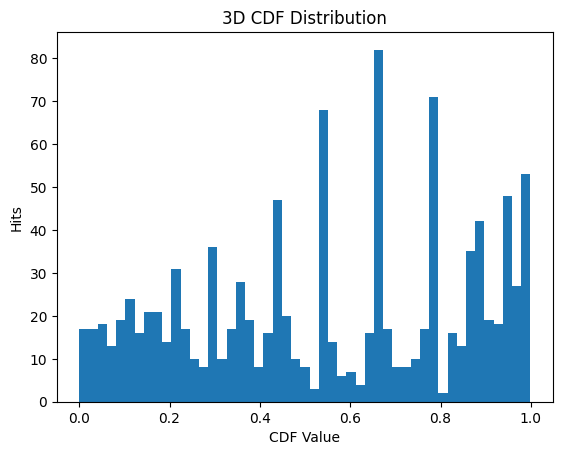

In [ ]:
cdf(np.array([-125.545, 719.033, -311.44, 2.31525, 1.0098]), EventdataSampled)

In [31]:
def compare_spline(fixed_coords: np.array, spline, frames)->None:
    # fixed_coords has shape 2, and should be [dr, dphi]
    # should be able to take either single frame or list of frames
    dR, dphi = fixed_coords
    dr_range = [dR - 20, dR + 20]
    dphi_range = [dphi - 0.1, dphi + 0.1]
    vals_in_bin = np.array([])
    try:
        i=0
        for frame in frames:
            i+=1
            print(i)
            truth = frame['I3MCTree'][1]
            Event = datacollect(frame)
            event_xyz = Event[:,0:3]
            event_t = Event[:,3]
    
    
    
            # Calculate Displacement Magnitude
            diff = np.array([truth.pos.x, truth.pos.y, truth.pos.z]) - event_xyz
            dr = np.linalg.norm(diff, axis=1)

            # Calculate Time Residual
            dt = abs(truth.time - event_t) - (1.34*dr/c * 1e9)
   

            # Construct Electron direction unit vector from zenith and azimuth
            Ex = np.sin(truth.dir.zenith)*np.cos(truth.dir.azimuth)
            Ey = np.sin(truth.dir.zenith)*np.sin(truth.dir.azimuth)
            Ez = np.cos(truth.dir.zenith)


            # Calculate angle between electron travel vector and displacement vector
            Eangle = np.array([Ex, Ey, Ez])
            Ephi = np.arccos(np.dot(diff, Eangle) / dr)

            params = np.column_stack([dr, Ephi, dt])

            mask = (params[:,0] > dr_range[0]) & (params[:,0] < dr_range[1]) & (params[:,1] > dphi_range[0]) & (params[:,1] < dphi_range[1])
            params_masked = params[mask]
        


            vals_in_bin = np.append(vals_in_bin, params_masked[:,2].T)
        print('List of Frames')

    except TypeError:
        print('one frame')
        frame = frames
        truth = frame['I3MCTree'][1]
        Event = datacollect(frame)
        event_xyz = Event[:,0:3]
        event_t = Event[:,3]
    
    
    
        # Calculate Displacement Magnitude
        diff = np.array([truth.pos.x, truth.pos.y, truth.pos.z]) - event_xyz
        dr = np.linalg.norm(diff, axis=1)

        # Calculate Time Residual
        dt = abs(truth.time - event_t) - (1.34*dr/c * 1e9)
   

        # Construct Electron direction unit vector from zenith and azimuth
        Ex = np.sin(truth.dir.zenith)*np.cos(truth.dir.azimuth)
        Ey = np.sin(truth.dir.zenith)*np.sin(truth.dir.azimuth)
        Ez = np.cos(truth.dir.zenith)


        # Calculate angle between electron travel vector and displacement vector
        Eangle = np.array([Ex, Ey, Ez])
        Ephi = np.arccos(np.dot(diff, Eangle) / dr)

        params = np.column_stack([dr, Ephi, dt])

        mask = (params[:,0] > dr_range[0]) & (params[:,0] < dr_range[1]) & (params[:,1] > dphi_range[0]) & (params[:,1] < dphi_range[1])
        params_masked = params[mask]
        vals_in_bin = params_masked[:,2].T
    #return vals_in_bin
    
    t = np.linspace(spline.extents[2][0], spline.extents[2][1], 1000)
    pdf = evalPdf(spline, dR, dphi, t)
    hist, edges = np.histogram(vals_in_bin, np.linspace(spline.extents[2][0], spline.extents[2][1], 500))
    plt.plot(t, pdf, color='red')
    plt.bar(edges[:-1], hist/sum(hist), width=edges[1] - edges[0])
    plt.yscale('log')
    plt.show()



In [30]:
datacollect(frame_list[-1])

array([[  40.14886317, -730.56178183, -100.00734329, 1506.8170166 ,
         144.00013527],
       [  40.05999013, -730.63419823,  -49.81027973, 1400.46948242,
         135.69884708],
       [  39.97872305, -730.59490015,  -49.82391396, 1317.42272949,
          52.44999103],
       ...,
       [ 480.00045719, -384.5132715 ,   49.93369306, 1546.06286621,
         217.92535164],
       [ 200.04807493, -314.85266775,   49.88027781, 1444.07275391,
         245.47932143],
       [ 280.04892487, -315.23550388,  -50.00990148, 1676.16271973,
         409.63836257]])

In [33]:
len(frame_list)

3842

In [32]:
compare_spline([20, 0.3], splinefit_3d, frame_list)


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


KeyboardInterrupt: 

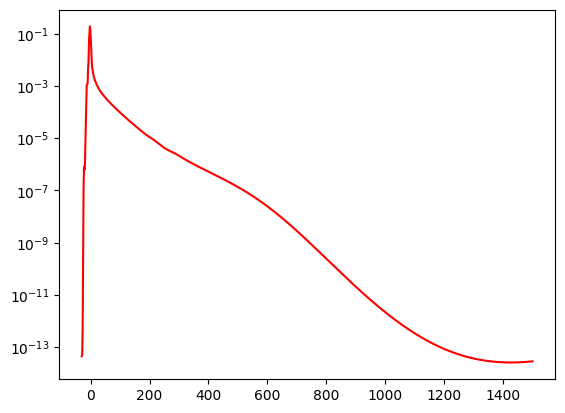

In [ ]:
t = np.linspace(-30, 1500, 1000)
pdf = evalPdf(splinefit_3d, 20, 0.3, t)
plt.plot(t, pdf, color = 'red')
plt.yscale('log')


In [ ]:
best_fit = minimizer(np.array([632.878,-456.534,-261.346, 0.938481, 2.22391,0]), EventData2)
cdf(best_fit['x'], EventData2)

KeyboardInterrupt: 

In [ ]:
def sample_dt(dr, dphi):
    pvalues = []
    spline=splinefit_3d 
    t = np.linspace(spline.extents[-1][0], spline.extents[-1][1], 2000)
    pdf = evalPdf(spline, dr, dphi, t)
    for dt in t:
        cdf = np.sum(pdf[:np.searchsorted(t, dt)])/np.sum(pdf)
        pvalues.append(cdf)
    return t, pvalues

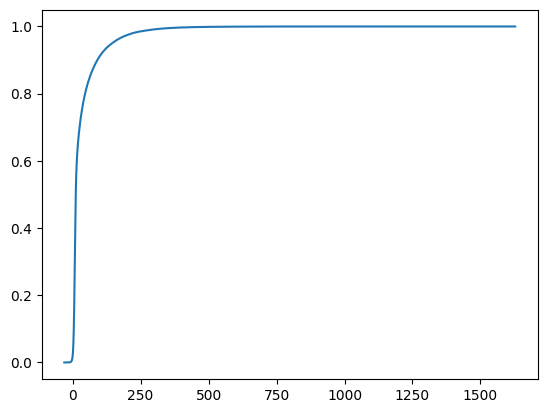

In [ ]:
t, p = sample_dt(100, 0)
plt.plot(t, p)